<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/MLP_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist


(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

def one_hot(y, num_classes=10):
    result = np.zeros((y.shape[0], num_classes))
    result[np.arange(y.shape[0]), y] = 1
    return result

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)



def relu(x):
    return np.maximum(0, x)
def relu_grad(x):
    return np.where(x > 0, 1.0, 0.0)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    #print(y_pred.shape)
    #print(y_true.shape)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def get_accuracy(y_pred, y_true):
    predictions = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    accuracy = np.mean(predictions == true_labels) * 100
    return accuracy

In [11]:
np.random.seed(42)

# Layer 1: Input (784) -> Hidden 1 (256)
W1 = np.random.randn(784, 256) * np.sqrt(2 / 784)
b1 = np.zeros((1, 256))

# Layer 2: Hidden 1 (256) -> Hidden 2 (128)
W2 = np.random.randn(256, 128) * np.sqrt(2 / 256)
b2 = np.zeros((1, 128))

# Layer 3: Hidden 2 (128) -> Hidden 3 (64)
W3 = np.random.randn(128, 64) * np.sqrt(2 / 128)
b3 = np.zeros((1, 64))

# Layer 4: Hidden 3 (64) -> Hidden 4 (32)
W4 = np.random.randn(64, 32) * np.sqrt(2 / 64)
b4 = np.zeros((1, 32))

# Layer 5: Hidden 4 (32) -> Output (10)
W5 = np.random.randn(32, 10) * np.sqrt(2 / 32)
b5 = np.zeros((1, 10))




In [12]:
def forward(X):
    # Layer 1: Input -> Hidden 1
    z1 = X @ W1 + b1
    a1 = relu(z1)

    # Layer 2: Hidden 1 -> Hidden 2
    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    # Layer 3: Hidden 2 -> Hidden 3
    z3 = a2 @ W3 + b3
    a3 = relu(z3)

    # Layer 4: Hidden 3 -> Hidden 4
    z4 = a3 @ W4 + b4
    a4 = relu(z4)

    # Layer 5: Hidden 4 -> Output
    z5 = a4 @ W5 + b5
    y_pred = softmax(z5)

    # Pack everything into the cache for backpropagation
    cache = (X, z1, a1, z2, a2, z3, a3, z4, a4, z5, y_pred)

    return y_pred, cache


def backward(y_true, cache):
    # Unpack the expanded cache
    X, z1, a1, z2, a2, z3, a3, z4, a4, z5, y_pred = cache
    m = X.shape[0]

    # ==========================================
    # Layer 5 (Output Layer)
    # ==========================================
    dz5 = (y_pred - y_true) / m
    dW5 = a4.T @ dz5
    db5 = np.sum(dz5, axis=0, keepdims=True)

    # ==========================================
    # Layer 4
    # ==========================================
    da4 = dz5 @ W5.T                 # Pass error backward through W5
    dz4 = da4 * relu_grad(z4)        # Derivative of ReLU at Layer 4
    dW4 = a3.T @ dz4
    db4 = np.sum(dz4, axis=0, keepdims=True)

    # ==========================================
    # Layer 3
    # ==========================================
    da3 = dz4 @ W4.T                 # Pass error backward through W4
    dz3 = da3 * relu_grad(z3)
    dW3 = a2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)

    # ==========================================
    # Layer 2
    # ==========================================
    da2 = dz3 @ W3.T                 # Pass error backward through W3
    dz2 = da2 * relu_grad(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # ==========================================
    # Layer 1
    # ==========================================
    da1 = dz2 @ W2.T                 # Pass error backward through W2
    dz1 = da1 * relu_grad(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Return all 10 gradient matrices
    return dW1, db1, dW2, db2, dW3, db3, dW4, db4, dW5, db5

In [13]:
X_val = X_train[-10000:]
Y_val = Y_train[-10000:]

#Keep the rest (everything except the last 10,000) for the Training Set
X_train = X_train[:-10000]
Y_train = Y_train[:-10000]

In [14]:
epochs = 10
batch_size = 64
learning_rate = 0.001
loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Standard cross-entropy loss (No L2 penalty)
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss

        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)

        # Unpack all 10 gradients for the 5-layer architecture
        dW1, db1, dW2, db2, dW3, db3, dW4, db4, dW5, db5 = gradients

        # Weight update (Standard SGD)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        W4 -= learning_rate * dW4
        b4 -= learning_rate * db4

        W5 -= learning_rate * dW5
        b5 -= learning_rate * db5

    # Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)

    # Validation phase
    y_val_pred, _ = forward(X_val)
    val_loss = cross_entropy(Y_val, y_val_pred)
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

Epoch 1/10 | Train Loss: 2.0979, Train Acc: 27.83% | Val Loss: 1.7580, Val Acc: 49.43%
Epoch 2/10 | Train Loss: 1.3941, Train Acc: 63.99% | Val Loss: 1.0236, Val Acc: 75.08%
Epoch 3/10 | Train Loss: 0.8654, Train Acc: 77.53% | Val Loss: 0.6821, Val Acc: 82.92%
Epoch 4/10 | Train Loss: 0.6395, Train Acc: 82.90% | Val Loss: 0.5355, Val Acc: 86.26%
Epoch 5/10 | Train Loss: 0.5271, Train Acc: 85.78% | Val Loss: 0.4553, Val Acc: 88.07%
Epoch 6/10 | Train Loss: 0.4596, Train Acc: 87.52% | Val Loss: 0.4042, Val Acc: 89.44%
Epoch 7/10 | Train Loss: 0.4131, Train Acc: 88.79% | Val Loss: 0.3683, Val Acc: 90.09%
Epoch 8/10 | Train Loss: 0.3798, Train Acc: 89.61% | Val Loss: 0.3401, Val Acc: 90.64%
Epoch 9/10 | Train Loss: 0.3537, Train Acc: 90.29% | Val Loss: 0.3194, Val Acc: 91.07%
Epoch 10/10 | Train Loss: 0.3324, Train Acc: 90.86% | Val Loss: 0.3017, Val Acc: 91.50%


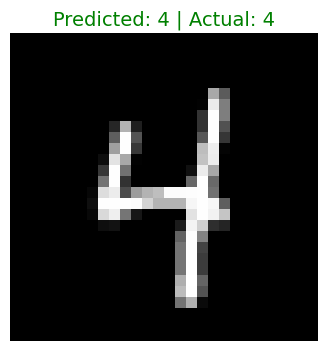

Network Predicts : 4 (Confidence: 90.42%)
Actual Truth     : 4


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def test_real_mnist_image(index):
    test_image = X_test[index].reshape(1, 784)

    true_label = np.argmax(Y_test[index])

    y_pred, _ = forward(test_image)

    predicted_label = np.argmax(y_pred, axis=1)[0]
    confidence = np.max(y_pred) * 100

    # 5. Visualize the image (reshaping back to 28x28 strictly for drawing)
    plt.figure(figsize=(4, 4))
    plt.imshow(test_image.reshape(28, 28), cmap='gray')

    # Change title color based on whether the network was correct
    title_color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Predicted: {predicted_label} | Actual: {true_label}", color=title_color, fontsize=14)
    plt.axis('off')
    plt.show()

    # 6. Print terminal results
    print(f"Network Predicts : {predicted_label} (Confidence: {confidence:.2f}%)")
    print(f"Actual Truth     : {true_label}")


test_real_mnist_image(19)

In [19]:
import cv2
import numpy as np

def test_custom_image(image_path):
    # 1. Load directly as a grayscale NumPy array
    img_array = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # 2. Resize to 28x28
    img_resized = cv2.resize(img_array, (28, 28))

    # 3. Invert colors (subtracting the matrix from 255 perfectly flips the colors)
    #img_inverted = 255 - img_resized

    # 4. Normalize and flatten into a 1D matrix
    X_test_image = (img_resized / 255.0).reshape(1, 784)

    # 5. Push through the frozen network (Inference)
    y_pred, _ = forward(X_test_image)

    final_prediction = np.argmax(y_pred, axis=1)[0]
    confidence = np.max(y_pred) * 100

    print(f"OpenCV Pipeline Predicts: {final_prediction} (Confidence: {confidence:.2f}%)")
# Execution:
test_custom_image("/content/2.jpg")

OpenCV Pipeline Predicts: 2 (Confidence: 96.22%)
